# Simulation Notebook

This notebook is the **run-generation stage** split from `FullEnergyOptimizationDemo11.ipynb`.

## Scope of this notebook
- Build workflow context and experiment settings.
- Execute optimization and Monte Carlo sweeps.
- Save raw run outputs and run-manifest CSV artifacts under `Output Data/...`.

## What is intentionally excluded
- Comparative post-processing and contour/report plotting.
- Follow-up calculations that derive analysis metrics from saved runs.

Use `analysis.ipynb` for all post-processing, metric aggregation, and plotting.


## Execution Guide

Run cells top-to-bottom to regenerate simulation artifacts.

1. Build context and baseline configuration.
2. Run baseline Monte Carlo and export baseline artifact CSVs.
3. Run Experiment 1/2/3/4-pre/4/4a/6 simulation cells.
4. Confirm each cell reports saved CSV paths.
5. Open `analysis.ipynb` for all downstream calculations and plots.


In [1]:
# Setup imports, repo-path resolution, and deterministic module reload for notebook execution.
import numpy as np
import pandas as pd

import sys
import importlib
from pathlib import Path

# Resolve repository root from current notebook location.
repo_root = Path.cwd().resolve()
if not (repo_root / '.git').exists():
    for parent in repo_root.parents:
        if (parent / '.git').exists():
            repo_root = parent
            break

source_dir = repo_root / 'Codes' / 'sourcecode'
source_dir_str = str(source_dir)

# Force this repo's sourcecode to the front to avoid stale/other-path imports.
if source_dir_str in sys.path:
    sys.path.remove(source_dir_str)
sys.path.insert(0, source_dir_str)

import stochastic_baseload_multiple_building_simulation_and_aggregation as sbm
sbm = importlib.reload(sbm)

# Export frequently used module functions to notebook scope.
prepare_workflow_inputs = sbm.prepare_workflow_inputs
summarize_dwelling_inputs = sbm.summarize_dwelling_inputs
run_monte_carlo_batch = sbm.run_monte_carlo_batch


## Build Inputs

In [4]:
# Paths and workflow parameters (edit only these values).
data_root = repo_root / 'Input data'
meta_path = data_root / 'Newcastle_Urban_Case_meta_updated.csv'
weather_path = data_root / 'NEcase_20_21_t2m_ssrd_30min.csv'
profile_root = data_root / 'Stochastic_Demands'

# Core workflow settings used to build context for all experiments.
workflow_cfg = {
    'step': '30min',
    'start_date': pd.Timestamp('2020-10-01'),
    'n_days': 365,
    'tariff_type': 'agile',
    'max_dwellings': None,   # Set an int for quick debug runs
    'random_seed': 42,
    'include_flex_setpoint': False, #always False
}

context = prepare_workflow_inputs(
    repo_root=repo_root,
    data_root=data_root,
    meta_path=meta_path,
    weather_path=weather_path,
    profile_root=profile_root,
    **workflow_cfg,
)

# Convenience aliases.
tariff = context['tariff']
dwelling_inputs = context['dwelling_inputs']
setpoint_sequences = context['setpoint_sequences']

print(f"Prepared {len(dwelling_inputs)} dwellings over {context['n_days']} days.")
print(f"Simulation window: {context['window'].index.min()} -> {context['window'].index.max()}")
print('Metadata columns:', list(context['meta'].columns))
print('Weather columns:', list(context['weather'].columns))


Prepared 147 dwellings over 365 days.
Simulation window: 2020-10-01 00:00:00 -> 2021-09-30 23:30:00
Metadata columns: ['Property_ID', 'Delivery_Contractor', 'Postcode_1', 'Participant_Age', 'EmployStatus', 'EmployType', 'HouseIncome', 'Date_Contact', 'Tenure', 'Tenure_Length', 'Social_Group', 'HP_Awareness', 'Reason_Sustainability', 'Sustainability_exp', 'Reason_Future', 'Future_exp', 'Reason_Upgrade', 'Upgrade_exp', 'Reason_Building', 'Building_exp', 'Reason_Financial', 'Financial_exp', 'Reason_Technology', 'Technology_exp', 'Reason_Research', 'Research_exp', 'Reason_Planned', 'Planned_exp', 'Reason_Replacement', 'Replacement_exp', 'Reason_Other', 'Other_exp', 'Date_Survey', 'Name_Survey', 'House_Type', 'House_Form', 'House_Env', 'House_Age', 'House_SAP', 'No_Adults', 'No_Child', 'No_Storeys', 'Total_Floor_Area', 'Habitable_Rooms', 'Bedrooms', 'Heated_rooms', 'Floor_Height', 'Wall_Type', 'Floor_Type', 'Roof_Type', 'Glazed_Type', 'Mains_Gas_Flag', 'Main_Fuel', 'Heat_Primary_Source', 'H

In [ ]:
# Preview sampled dwelling inputs (input sanity check only; no plotting).
preview_df = summarize_dwelling_inputs(dwelling_inputs, n_preview=3)
display(preview_df)


## Built Input Diagnostics

,dwelling_id,occupants,R1,C1,g,profile_path,requested_plot_start,plotted_start,plotted_end,plotted_days
0,0,1,0.006439,1.818650e+07,0.249881,E:\Github\LV-network\Input data\Stochastic_Dem...,2020-10-01,2020-10-01,2021-03-31 23:30:00,182.0


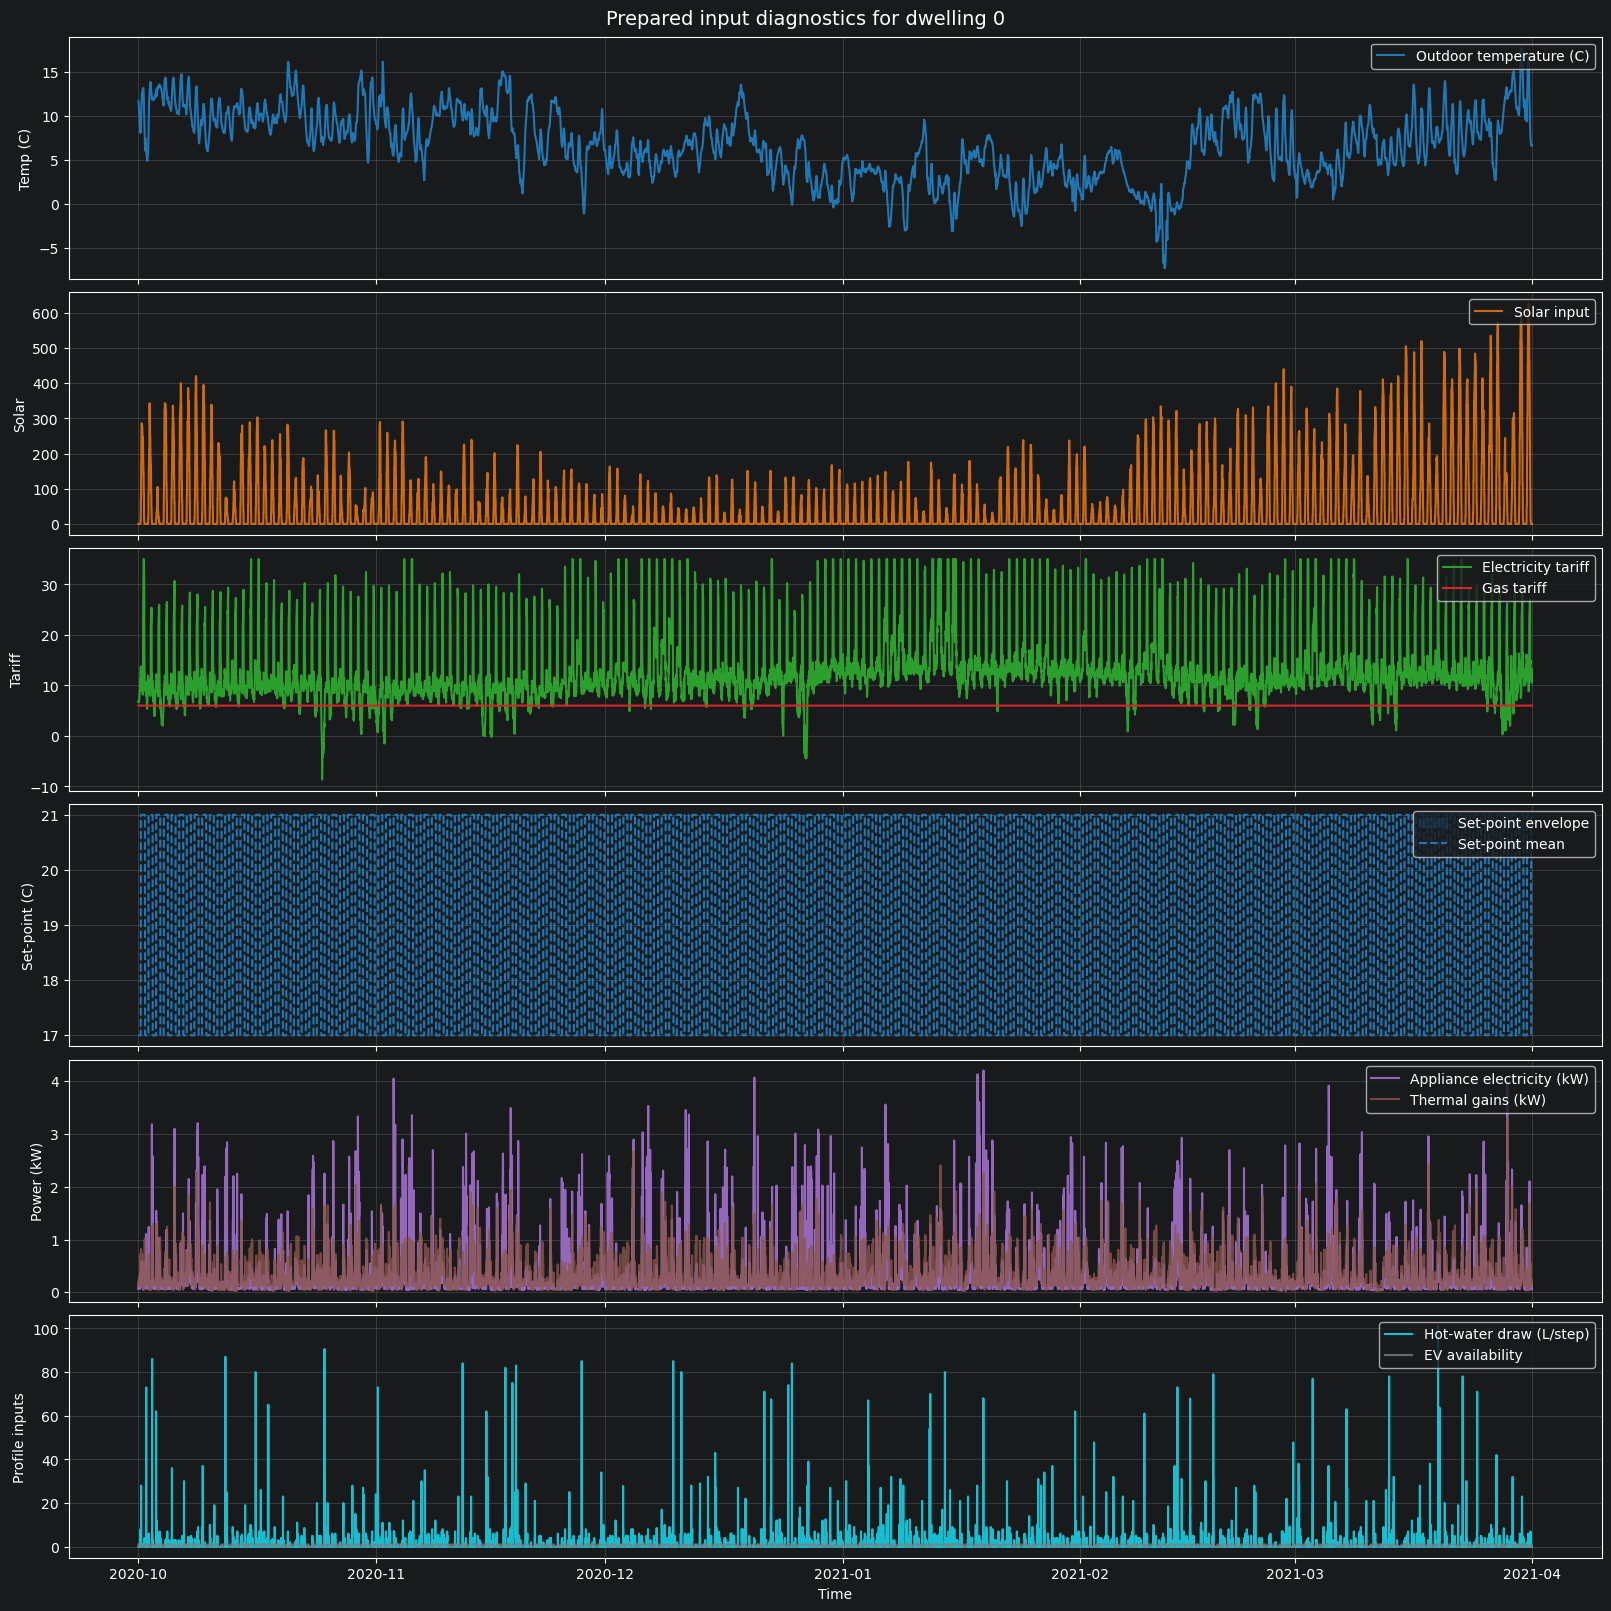

In [9]:
# Plot the prepared workflow inputs before running any optimization.
# This is useful for checking time alignment, magnitudes, and seasonal patterns.
input_plot_dwelling_id = next(iter(dwelling_inputs))  # Change to inspect another dwelling.
input_plot_start_date = '2020-10-01'  # Use a string, pd.Timestamp(...), or a tuple like (2021, 11, 1). Bare 2021-11-01 is invalid Python.
input_plot_days = 182  # Use None to show the remaining prepared period from the chosen start.

input_plot_dwelling_id = int(input_plot_dwelling_id)
if input_plot_dwelling_id not in dwelling_inputs:
    raise KeyError(f'Unknown dwelling id for input plot: {input_plot_dwelling_id}')

input_plot_all_index = context['window'].index
input_plot_steps_per_day = int(context['steps_per_day'])
if input_plot_start_date is None:
    input_plot_start_ts = input_plot_all_index[0]
elif isinstance(input_plot_start_date, (tuple, list)):
    input_plot_start_ts = pd.Timestamp(*input_plot_start_date)
else:
    input_plot_start_ts = pd.Timestamp(input_plot_start_date)
if input_plot_start_ts < input_plot_all_index[0] or input_plot_start_ts > input_plot_all_index[-1]:
    raise ValueError(
        f'input_plot_start_date={input_plot_start_ts} is outside prepared context range '
        f'[{input_plot_all_index[0]} .. {input_plot_all_index[-1]}]'
    )
input_plot_start_pos = int(input_plot_all_index.searchsorted(input_plot_start_ts, side='left'))
if input_plot_start_pos >= len(input_plot_all_index):
    raise ValueError('No plot data available at or after input_plot_start_date.')
input_plot_available_steps = len(input_plot_all_index) - input_plot_start_pos
if input_plot_days is None:
    input_plot_steps = input_plot_available_steps
else:
    input_plot_steps = min(input_plot_available_steps, int(input_plot_days) * input_plot_steps_per_day)
if input_plot_steps <= 0:
    raise ValueError('input_plot_days must be positive or None.')

input_plot_end_pos = input_plot_start_pos + input_plot_steps
input_plot_index = input_plot_all_index[input_plot_start_pos:input_plot_end_pos]
input_plot_dwelling = dwelling_inputs[input_plot_dwelling_id]

# Build the plotted time-series from the already prepared context.
input_base_kw = np.asarray(input_plot_dwelling['base_electric'], dtype=float)[input_plot_start_pos:input_plot_end_pos] / 1000.0
input_hw_liters = np.asarray(input_plot_dwelling['hw_demand'], dtype=float)[input_plot_start_pos:input_plot_end_pos]
input_gains_kw = np.asarray(input_plot_dwelling['thermal_gains'], dtype=float)[input_plot_start_pos:input_plot_end_pos] / 1000.0
input_ev_availability = np.asarray(input_plot_dwelling['ev_availability'], dtype=float)[input_plot_start_pos:input_plot_end_pos]
input_tout = np.asarray(context['Tout'], dtype=float)[input_plot_start_pos:input_plot_end_pos]
input_solar = np.asarray(context['S'], dtype=float)[input_plot_start_pos:input_plot_end_pos]
input_elec_tariff = np.asarray(context['tariff']['elec_price'], dtype=float)[input_plot_start_pos:input_plot_end_pos]
input_gas_tariff = np.asarray(context['tariff']['gas_price'], dtype=float)[input_plot_start_pos:input_plot_end_pos]

# Plot the comfort schedule envelope so it is easy to spot a set-point issue.
input_setpoint_stack = np.vstack([
    np.asarray(seq, dtype=float)[input_plot_start_pos:input_plot_end_pos]
    for seq in context['setpoint_sequences']
    if len(np.asarray(seq).reshape(-1)) >= input_plot_end_pos
])
input_setpoint_mean = input_setpoint_stack.mean(axis=0)
input_setpoint_min = input_setpoint_stack.min(axis=0)
input_setpoint_max = input_setpoint_stack.max(axis=0)

# Basic alignment checks before plotting.
input_lengths = {
    'time_index': len(input_plot_index),
    'Tout': len(input_tout),
    'S': len(input_solar),
    'elec_tariff': len(input_elec_tariff),
    'gas_tariff': len(input_gas_tariff),
    'setpoint_mean': len(input_setpoint_mean),
    'base_electric': len(input_base_kw),
    'hw_demand': len(input_hw_liters),
    'thermal_gains': len(input_gains_kw),
    'ev_availability': len(input_ev_availability),
}
if len(set(input_lengths.values())) != 1:
    raise ValueError(f'Built input length mismatch: {input_lengths}')

display(pd.DataFrame([
    {
        'dwelling_id': input_plot_dwelling_id,
        'occupants': input_plot_dwelling['occ'],
        'R1': float(input_plot_dwelling['meta'][context['r_col']]),
        'C1': float(input_plot_dwelling['meta'][context['c_col']]),
        'g': float(input_plot_dwelling['meta'][context['g_col']]),
        'profile_path': input_plot_dwelling['profile_path'],
        'requested_plot_start': input_plot_start_ts,
        'plotted_start': input_plot_index.min(),
        'plotted_end': input_plot_index.max(),
        'plotted_days': input_plot_steps / input_plot_steps_per_day,
    }
]))

fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True, constrained_layout=True)

axes[0].plot(input_plot_index, input_tout, color='tab:blue', label='Outdoor temperature (C)')
axes[0].set_ylabel('Temp (C)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(input_plot_index, input_solar, color='tab:orange', alpha=0.8, label='Solar input')
axes[1].set_ylabel('Solar')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(input_plot_index, input_elec_tariff, color='tab:green', label='Electricity tariff')
axes[2].plot(input_plot_index, input_gas_tariff, color='tab:red', label='Gas tariff')
axes[2].set_ylabel('Tariff')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

axes[3].fill_between(input_plot_index, input_setpoint_min, input_setpoint_max, color='tab:blue', alpha=0.15, label='Set-point envelope')
axes[3].plot(input_plot_index, input_setpoint_mean, color='tab:blue', linestyle='--', label='Set-point mean')
axes[3].set_ylabel('Set-point (C)')
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

axes[4].plot(input_plot_index, input_base_kw, color='tab:purple', label='Appliance electricity (kW)')
axes[4].plot(input_plot_index, input_gains_kw, color='tab:brown', alpha=0.8, label='Thermal gains (kW)')
axes[4].set_ylabel('Power (kW)')
axes[4].legend(loc='upper right')
axes[4].grid(True, alpha=0.3)

axes[5].step(input_plot_index, input_hw_liters, where='post', color='tab:cyan', label='Hot-water draw (L/step)')
axes[5].step(input_plot_index, input_ev_availability, where='post', color='tab:gray', alpha=0.8, label='EV availability')
axes[5].set_ylabel('Profile inputs')
axes[5].set_xlabel('Time')
axes[5].legend(loc='upper right')
axes[5].grid(True, alpha=0.3)

fig.suptitle(f'Prepared input diagnostics for dwelling {input_plot_dwelling_id}', fontsize=14)
plt.show()


## Baseline Monte Carlo Runs

In [10]:
# === Monte Carlo configuration (edit only these values) ===
selected_dwellings = 2  # Example: [1, 2] for subset
mc_runs = 10
case = 'monovalent'  # 'monovalent', 'hybrid', or 'boiler_only'
output_subdir = 'Test'
capacity_candidates_kw = np.arange(7.0, 20, 0.5)

# Optional parameter overrides passed into run_monte_carlo_batch.
# Leave dictionaries empty to use built-in defaults.
optim_params_cfg = {
    'tol': 1.0,
    'enforce_upper_comfort_bound': False,  # Set False to remove the upper indoor-temperature limit.
    'COP': 3.5,
    'etaB': 0.9,
    'T0': 21.0,
    # 'Qhp_max': 7000.0,  # W; if set, overrides HP capacity sweep
    # 'Qbo_max': 0.0,     # W; if set, overrides case boiler capacity
}

# EV charging and SOC assumptions for optimization.
ev_params_cfg = {
    'ev_capacity': 60.0,
    'ev_soc_init': 48.0,
    'ev_target': 48.0,
    'ev_charge_max': 5.0,
    'eta_ev_charge': 0.95,
    'ev_min_final_fraction': 0.8,
    'ev_retention': 0.999,
    # EV feasibility precheck before optimization; infeasible samples are resampled.
    'ev_precheck_enabled': True,
    'ev_precheck_max_resamples': 50,
}

# Separate hot-water configs by case to avoid accidental cross-case overrides.
# Monovalent hot-water settings.
mhp_hw_params_cfg = {
    'hw_mode': 'hp_storage',  # 'hybrid_direct' | 'boiler_only' | 'hp_storage'
    'V_stor': 0.2,
    'V_stor_init': 0.12,
    'T_mains': 10.0,
    'T_hw_supply': 40.0,
    'Q_bo_hw_max': 0.0,
}

# Hybrid hot-water settings.
hhp_hw_params_cfg = {
    # Keep empty to preserve project defaults for HHP (4kW HP + 30kW boiler setup).
    # Example override:
    'hw_mode': 'boiler_only',
    'Q_hp_hw_max': 0.0,
}

# Boiler-only heating settings (space + DHW by gas boiler, HP disabled).
boiler_hw_params_cfg = {
    'hw_mode': 'boiler_only',
    'Q_hp_hw_max': 0.0,
    'V_stor': 0.0,
    'V_stor_init': 0.0,
    'T_mains': 10.0,
    'T_hw_supply': 40.0,
}
boiler_optim_params_cfg = {
    'Qhp_max': 0.0,
    'Qbo_max': 30000.0,
}

# Case-specific configuration map used by baseline MC and Experiment 6.
mc_case_cfg = {
    'hybrid': {'optim': {}, 'hw': dict(hhp_hw_params_cfg)},
    'monovalent': {'optim': {}, 'hw': dict(mhp_hw_params_cfg)},
    'boiler_only': {'optim': dict(boiler_optim_params_cfg), 'hw': dict(boiler_hw_params_cfg)},
}
if case not in mc_case_cfg:
    raise ValueError(f"Unsupported case '{case}'. Use one of: {sorted(mc_case_cfg)}")

day_ahead = True
save_outputs = True
show_progress = True

# Summary plot envelope settings.
envelope_mode = 'extreme'  # 'percentile' or 'extreme'
envelope_low_pct = 10.0
envelope_high_pct = 90.0



In [ ]:
# Run Monte Carlo batch using configured parameters.
active_case_cfg = mc_case_cfg[case]
active_optim_params_cfg = dict(optim_params_cfg)
active_optim_params_cfg.update(dict(active_case_cfg.get('optim', {})))
active_hw_params_cfg = dict(active_case_cfg.get('hw', {}))

# Execute MC optimization with configured parameter overrides.
mc_results = run_monte_carlo_batch(
    context,
    mc_runs=mc_runs,
    case=case,
    output_subdir=output_subdir,
    selected_dwellings=selected_dwellings,
    capacity_candidates_kw=capacity_candidates_kw,
    optim_params_cfg=active_optim_params_cfg,
    ev_params_cfg=ev_params_cfg,
    hw_params_cfg=active_hw_params_cfg,
    day_ahead=day_ahead,
    save_outputs=save_outputs,
    show_progress=show_progress,
)

# Convenience aliases for downstream artifact export.
profile_usage = mc_results.get('profile_usage', [])
dwellings_to_run = mc_results['dwellings_to_run']
case_label = mc_results['case_label']

print(
    f"MC completed: case={case_label}, runs={mc_results['mc_runs']}, "
    f"dwellings={len(dwellings_to_run)}, output_dir={mc_results['output_dir']}"
)

if mc_results['summary_runs']:
    status_counts = pd.concat(mc_results['summary_runs'], ignore_index=True)['solve_status'].value_counts(dropna=False)
    print('Solve status counts:', status_counts.to_dict())

failure_reasons = mc_results.get('failure_reasons', {})
if failure_reasons:
    print('Top failure reasons:')
    for msg, cnt in sorted(failure_reasons.items(), key=lambda kv: kv[1], reverse=True)[:5]:
        print(f'  {cnt}x  {msg}')


### Baseline Artifact Export (No Plotting)


In [ ]:
# Export baseline MC artifacts for analysis notebook consumption.
baseline_output_dir = Path(mc_results['output_dir'])
baseline_artifact_dir = baseline_output_dir / 'artifacts'
baseline_artifact_dir.mkdir(parents=True, exist_ok=True)

# Profile-usage samples selected during stochastic input generation.
baseline_profile_usage_df = pd.DataFrame(profile_usage)
baseline_profile_usage_csv = baseline_artifact_dir / 'baseline_profile_usage.csv'
baseline_profile_usage_df.to_csv(baseline_profile_usage_csv, index=False)

# Per-run solver outputs from run_monte_carlo_batch.
if mc_results['summary_runs']:
    baseline_run_summary_df = pd.concat(mc_results['summary_runs'], ignore_index=True)
else:
    baseline_run_summary_df = pd.DataFrame()
baseline_run_summary_csv = baseline_artifact_dir / 'baseline_run_summary.csv'
baseline_run_summary_df.to_csv(baseline_run_summary_csv, index=False)

# Explicit run-file index for downstream parsing.
def _baseline_run_number_from_path(path_obj: Path) -> int:
    try:
        return int(path_obj.stem.split('_')[-1])
    except Exception:
        return -1

baseline_run_files = sorted(baseline_output_dir.glob('mc_run_*.csv'), key=_baseline_run_number_from_path)
baseline_run_files_df = pd.DataFrame(
    {
        'run': [_baseline_run_number_from_path(p) for p in baseline_run_files],
        'path': [str(p) for p in baseline_run_files],
    }
)
baseline_run_files_csv = baseline_artifact_dir / 'baseline_run_files.csv'
baseline_run_files_df.to_csv(baseline_run_files_csv, index=False)

print(f"Saved baseline profile usage CSV: {baseline_profile_usage_csv}")
print(f"Saved baseline run summary CSV: {baseline_run_summary_csv}")
print(f"Saved baseline run file index CSV: {baseline_run_files_csv}")
print(f"Indexed run files: {len(baseline_run_files_df)}")


## Simulation Experiments

### Experiment 1 / 2 (Run Generation Only)

Experiment 3 run-generation is merged into the unified Experiment 6 runner below.
Use Experiment 6 with single-case + zero-offset settings for Experiment 3-equivalent outputs.


In [ ]:
# === Experiment 1: EV charging power sweep (run generation only) ===
# Runs MHP and HHP sweeps and writes run outputs + manifest CSV.

exp1_ev_limits_kw = np.arange(3, 12, 2)  # 3, 5, 7, 9, 11
exp1_output_subdir_root = 'Experiment 1 EV Sweep'
exp1_output_root = Path(repo_root) / 'Output Data' / exp1_output_subdir_root
exp1_output_root.mkdir(parents=True, exist_ok=True)

# Case definitions:
# - MHP uses configured optimization overrides + monovalent DHW settings.
# - HHP keeps project defaults unless explicit HHP overrides are provided.
exp1_case_cfg = [
    {
        'case_label': 'MHP',
        'case_mode': 'monovalent',
        'optim_params_cfg': dict(optim_params_cfg),
        'hw_params_cfg': dict(mhp_hw_params_cfg),
        'capacity_candidates_kw': capacity_candidates_kw,
    },
    {
        'case_label': 'HHP',
        'case_mode': 'hybrid',
        'optim_params_cfg': {},
        'hw_params_cfg': dict(hhp_hw_params_cfg),
        'capacity_candidates_kw': None,
    },
]

def _exp1_status_counts_from_mc(mc_out: dict) -> dict:
    counts = {}
    for df in mc_out.get('summary_runs', []):
        if not isinstance(df, pd.DataFrame) or df.empty or ('solve_status' not in df.columns):
            continue
        vc = df['solve_status'].dropna().astype(str).value_counts(dropna=False)
        for k, v in vc.items():
            counts[k] = int(counts.get(k, 0)) + int(v)
    return counts

exp1_rows = []
for exp1_cfg in exp1_case_cfg:
    for exp1_ev_power_kw in exp1_ev_limits_kw:
        exp1_ev_params_cfg = dict(ev_params_cfg)
        exp1_ev_params_cfg['ev_charge_max'] = float(exp1_ev_power_kw)

        exp1_case_subdir = (
            f"{exp1_output_subdir_root}/"
            f"{exp1_cfg['case_label'].lower()}_ev_{int(round(float(exp1_ev_power_kw)))}kW"
        )

        exp1_mc = run_monte_carlo_batch(
            context,
            mc_runs=mc_runs,
            case=exp1_cfg['case_mode'],
            output_subdir=exp1_case_subdir,
            selected_dwellings=selected_dwellings,
            capacity_candidates_kw=exp1_cfg['capacity_candidates_kw'],
            optim_params_cfg=exp1_cfg['optim_params_cfg'],
            ev_params_cfg=exp1_ev_params_cfg,
            hw_params_cfg=exp1_cfg['hw_params_cfg'],
            day_ahead=day_ahead,
            save_outputs=True,
            show_progress=show_progress,
        )

        exp1_status_counts = _exp1_status_counts_from_mc(exp1_mc)
        exp1_peaks = np.asarray(
            [float(np.nanmax(np.asarray(curve, dtype=float))) for curve in exp1_mc.get('agg_curves', [])],
            dtype=float,
        )
        if exp1_peaks.size:
            exp1_peak_mean = float(np.nanmean(exp1_peaks))
            exp1_peak_p95 = float(np.nanpercentile(exp1_peaks, 95))
            exp1_peak_max = float(np.nanmax(exp1_peaks))
        else:
            exp1_peak_mean = np.nan
            exp1_peak_p95 = np.nan
            exp1_peak_max = np.nan

        exp1_rows.append(
            {
                'case_label': exp1_cfg['case_label'],
                'case_mode': exp1_cfg['case_mode'],
                'ev_charge_max_kw': float(exp1_ev_power_kw),
                'mc_runs': int(mc_runs),
                'n_dwellings': len(exp1_mc['dwellings_to_run']),
                'status_counts': exp1_status_counts,
                'mean_peak_kw': exp1_peak_mean,
                'p95_peak_kw': exp1_peak_p95,
                'max_peak_kw': exp1_peak_max,
                'output_dir': str(exp1_mc['output_dir']),
            }
        )

exp1_summary_df = pd.DataFrame(exp1_rows).sort_values(['case_label', 'ev_charge_max_kw']).reset_index(drop=True)
exp1_summary_csv = exp1_output_root / 'exp1_run_manifest.csv'
exp1_summary_df.to_csv(exp1_summary_csv, index=False)

print(f"Saved Experiment 1 run manifest: {exp1_summary_csv}")
display(exp1_summary_df)


In [ ]:
# === Experiment 2: HHP convergence at EV 5 kW (run generation only) ===
# This cell only ensures required runs are present and records run manifests.

exp2_case = 'hybrid'
exp2_ev_charge_max_kw = 5.0
exp2_total_target_runs = 200

# Continuation controls.
exp2_continue_from_existing = True
exp2_existing_completed_runs = 164

exp2_output_subdir = 'Convergence Plot'
exp2_output_dir = Path(repo_root) / 'Output Data' / exp2_output_subdir
exp2_output_dir.mkdir(parents=True, exist_ok=True)

# Use HHP hot-water configuration and fixed EV charger power.
exp2_hw_params_cfg = dict(hhp_hw_params_cfg)
exp2_ev_params_cfg = dict(ev_params_cfg)
exp2_ev_params_cfg['ev_charge_max'] = float(exp2_ev_charge_max_kw)

def _exp2_run_number_from_path(path_obj: Path) -> int:
    try:
        return int(path_obj.stem.split('_')[-1])
    except Exception:
        return -1

# Validate continuation requirements before starting new runs.
if exp2_continue_from_existing and exp2_existing_completed_runs > 0:
    exp2_existing_run_files = sorted(exp2_output_dir.glob('mc_run_*.csv'), key=_exp2_run_number_from_path)
    exp2_run_file_map = {_exp2_run_number_from_path(p): p for p in exp2_existing_run_files}
    exp2_required_runs = list(range(1, int(exp2_existing_completed_runs) + 1))
    exp2_missing_runs = [r for r in exp2_required_runs if r not in exp2_run_file_map]
    if exp2_missing_runs:
        raise FileNotFoundError(
            f"Missing existing run CSV files for continuation: {exp2_missing_runs}. "
            f"Expected in: {exp2_output_dir}"
        )

if exp2_continue_from_existing:
    exp2_run_index_start = int(exp2_existing_completed_runs)
    exp2_new_runs = max(0, int(exp2_total_target_runs) - int(exp2_existing_completed_runs))
else:
    exp2_run_index_start = 0
    exp2_new_runs = int(exp2_total_target_runs)

exp2_mc_results = {'summary_runs': []}
if exp2_new_runs > 0:
    exp2_mc_results = run_monte_carlo_batch(
        context,
        mc_runs=exp2_new_runs,
        run_index_start=exp2_run_index_start,
        case=exp2_case,
        output_subdir=exp2_output_subdir,
        selected_dwellings=selected_dwellings,
        capacity_candidates_kw=None,
        optim_params_cfg=optim_params_cfg,
        ev_params_cfg=exp2_ev_params_cfg,
        hw_params_cfg=exp2_hw_params_cfg,
        day_ahead=day_ahead,
        save_outputs=True,
        show_progress=show_progress,
    )

exp2_status_counts = {}
for df in exp2_mc_results.get('summary_runs', []):
    if not isinstance(df, pd.DataFrame) or df.empty or ('solve_status' not in df.columns):
        continue
    vc = df['solve_status'].dropna().astype(str).value_counts(dropna=False)
    for k, v in vc.items():
        exp2_status_counts[k] = int(exp2_status_counts.get(k, 0)) + int(v)

exp2_run_files_after = sorted(exp2_output_dir.glob('mc_run_*.csv'), key=_exp2_run_number_from_path)
exp2_run_file_index_df = pd.DataFrame(
    {
        'run': [_exp2_run_number_from_path(p) for p in exp2_run_files_after],
        'path': [str(p) for p in exp2_run_files_after],
    }
)
exp2_run_file_index_csv = exp2_output_dir / 'exp2_run_file_index.csv'
exp2_run_file_index_df.to_csv(exp2_run_file_index_csv, index=False)

exp2_manifest_df = pd.DataFrame(
    [
        {
            'case': exp2_case,
            'ev_charge_max_kw': float(exp2_ev_charge_max_kw),
            'continue_from_existing': bool(exp2_continue_from_existing),
            'existing_runs_requested': int(exp2_existing_completed_runs),
            'runs_added': int(exp2_new_runs),
            'target_total_runs': int(exp2_total_target_runs),
            'final_run_files_found': int(len(exp2_run_file_index_df)),
            'status_counts_new_runs': exp2_status_counts,
            'output_dir': str(exp2_output_dir),
            'run_file_index_csv': str(exp2_run_file_index_csv),
        }
    ]
)
exp2_manifest_csv = exp2_output_dir / 'exp2_run_manifest.csv'
exp2_manifest_df.to_csv(exp2_manifest_csv, index=False)

print(f"Saved Experiment 2 run manifest: {exp2_manifest_csv}")
print(f"Saved Experiment 2 run-file index: {exp2_run_file_index_csv}")
display(exp2_manifest_df)


In [ ]:
# === Experiment 3 merged into Experiment 6 ===
# Use the unified Experiment 6 cell for both workflows:
# - Experiment 6 scan mode (multi-case and offsets)
# - Experiment 3-equivalent mode (single case, zero offset)
#
# For Experiment 3-equivalent behavior, set in Experiment 6 cell:
# exp6_cases = ['monovalent']         # or ['hybrid'] / ['boiler_only']
# exp6_offset_max_hours_list = [0.0]  # no random tariff offset
# exp6_selected_dwellings = [1, 2, 3] # None for all dwellings
# exp6_bypass_ev = True                # disable EV from optimization
# exp6_tariff_type = 'flat'           # 'flat', 'cozy', or 'agile'
# exp6_output_layout = 'single_case_folder'
# exp6_continue_from_existing = False
print('Experiment 3 run-generation is merged into Experiment 6 (see unified Experiment 6 cell).')


### Experiment 4 Family (Moved to Analysis)

Experiment 4 pre-check, Experiment 4, and Experiment 4a are cache-based computations
from existing single-dwelling run outputs. They are executed in `analysis.ipynb`.


In [ ]:
# Experiment 4 pre-check execution is handled in analysis.ipynb.
print("Run Experiment 4 pre-check in analysis.ipynb (cache-based, no new dwelling optimization runs).")


### Experiment 4 (Moved to Analysis)

Cache-based EV penetration x HHP-share table generation is in `analysis.ipynb`.


In [ ]:
# Experiment 4 execution is handled in analysis.ipynb.
print("Run Experiment 4 in analysis.ipynb (cache-based mixing over existing run outputs).")


### Experiment 4a (Moved to Analysis)

Cache-based fixed-EV HHP/MHP/boiler sweep generation is in `analysis.ipynb`.


In [ ]:
# Experiment 4a execution is handled in analysis.ipynb.
print("Run Experiment 4a in analysis.ipynb (cache-based mixing over existing run outputs).")


### Experiment 6 (Unified Runner for Exp3 + Exp6)


In [13]:
# === Experiment 6: Unified runner (also supports Experiment 3-equivalent runs) ===
# This cell can run:
# - Experiment 6 scan: multi-case + offset sweep (default layout: randomized offset folders)
# - Experiment 3-equivalent: single case + zero offset + optional flat tariff

import re
from tqdm.auto import tqdm

# Core setup: target total runs per dwelling-case-offset configuration.
exp6_cases =['boiler_only','hybrid'] #['hybrid', 'monovalent', 'boiler_only']
exp6_target_total_runs = 5
exp6_offset_max_hours_list = [2]  # Exp3-equivalent: set [0.0]
exp6_selected_dwellings = None  # None = all dwellings; int/str/list = subset (e.g., [1, 2, 7])
exp6_offset_seed_base = 42
exp6_show_progress = True
exp6_continue_from_existing = True  # Exp3-equivalent: typically False for fresh overwrite workflow

exp6_tariff_type = 'agile'  # supported: 'flat', 'cozy', 'agile'
exp6_output_layout = 'offset_scan'  # 'offset_scan' or 'single_case_folder'
exp6_start_date =pd.Timestamp('2020-10-01')  # e.g., pd.Timestamp('2021-01-01'); None uses base context start
exp6_n_days = 365  # e.g., 365; None uses base context requested horizon
exp6_bypass_ev = True  # True disables EV variables/constraints in optimization

In [14]:
# Optional EV configuration for this experiment.
exp6_ev_charge_max_kw = 5.0
exp6_ev_params_cfg = dict(ev_params_cfg)
if bool(exp6_bypass_ev):
    exp6_ev_params_cfg.update(
        {
            'ev_capacity': 0.0,
            'ev_soc_init': 0.0,
            'ev_target': 0.0,
            'ev_charge_max': 0.0,
            'ev_min_final_fraction': 0.0,
            'ev_retention': 1.0,
            'ev_precheck_enabled': False,
        }
    )
    exp6_ev_charge_max_kw_effective = 0.0
else:
    exp6_ev_params_cfg['ev_charge_max'] = float(exp6_ev_charge_max_kw)
    exp6_ev_charge_max_kw_effective = float(exp6_ev_charge_max_kw)
exp6_ev_kw_txt = str(int(round(exp6_ev_charge_max_kw_effective))) if abs(exp6_ev_charge_max_kw_effective - round(exp6_ev_charge_max_kw_effective)) < 1e-9 else str(exp6_ev_charge_max_kw_effective).replace('.', 'p')

# Keep separate optimization/hot-water parameter sets for each case.
exp6_case_cfg = {
    'hybrid': {'optim': {}, 'hw': dict(hhp_hw_params_cfg)},
    'monovalent': {'optim': {}, 'hw': dict(mhp_hw_params_cfg)},
    'boiler_only': {'optim': dict(boiler_optim_params_cfg), 'hw': dict(boiler_hw_params_cfg)},
}
missing_cases = [c for c in exp6_cases if c not in exp6_case_cfg]
if missing_cases:
    raise ValueError(f"Missing exp6_case_cfg entries for: {missing_cases}")

exp6_tariff_type = str(exp6_tariff_type).strip().lower()
if exp6_tariff_type not in {'flat', 'cozy', 'agile'}:
    raise ValueError("exp6_tariff_type must be one of: 'flat', 'cozy', 'agile'")

exp6_output_layout = str(exp6_output_layout).strip().lower()
if exp6_output_layout not in {'offset_scan', 'single_case_folder'}:
    raise ValueError("exp6_output_layout must be one of: 'offset_scan', 'single_case_folder'")

# Build Experiment 6 context from the already prepared workflow context.
exp6_context = dict(context)
exp6_base_window = context['window']
exp6_base_start_date = pd.Timestamp(exp6_base_window.index[0]).normalize()
exp6_base_end_date = pd.Timestamp(exp6_base_window.index[-1]).normalize()
exp6_effective_start_date = exp6_base_start_date if exp6_start_date is None else pd.Timestamp(exp6_start_date).normalize()
exp6_effective_n_days = int(context['n_days']) if exp6_n_days is None else int(exp6_n_days)
if exp6_effective_n_days <= 0:
    raise ValueError('exp6_n_days must be > 0 when provided.')
if (exp6_effective_start_date < exp6_base_start_date) or (exp6_effective_start_date > exp6_base_end_date):
    raise ValueError(
        f"exp6_start_date={exp6_effective_start_date.date()} is outside prepared context range "
        f"[{exp6_base_start_date.date()} .. {exp6_base_end_date.date()}]."
    )

exp6_end_exclusive = exp6_effective_start_date + pd.Timedelta(days=exp6_effective_n_days)
exp6_window = exp6_base_window.loc[
    exp6_effective_start_date : exp6_end_exclusive - pd.Timedelta(exp6_context['step'])
]
if exp6_window.empty:
    raise ValueError(
        f"Selected Experiment 6 period is empty. start={exp6_effective_start_date.date()}, "
        f"n_days={exp6_effective_n_days}, context_end={exp6_base_window.index.max()}"
    )
exp6_steps_per_day = int(exp6_context['steps_per_day'])
exp6_trailing_steps = int(len(exp6_window) % exp6_steps_per_day)
if exp6_trailing_steps:
    exp6_window = exp6_window.iloc[:-exp6_trailing_steps]
if len(exp6_window) < exp6_steps_per_day:
    raise ValueError(
        f"Experiment 6 selected period is shorter than one day after alignment: {len(exp6_window)} steps."
    )

exp6_context['window'] = exp6_window
exp6_context['n_days'] = int(len(exp6_window) // exp6_steps_per_day)
exp6_context['requested_n_days'] = int(exp6_effective_n_days)
exp6_context['n_steps'] = int(len(exp6_window))
exp6_tout_series = pd.Series(np.asarray(context['Tout'], dtype=float), index=exp6_base_window.index)
exp6_s_series = pd.Series(np.asarray(context['S'], dtype=float), index=exp6_base_window.index)
exp6_context['Tout'] = exp6_tout_series.loc[exp6_window.index].to_numpy(dtype=float)
exp6_context['S'] = exp6_s_series.loc[exp6_window.index].to_numpy(dtype=float)

exp6_tariff_df = sbm.build_tariff(
    exp6_window.index[0],
    n_days=exp6_context['n_days'],
    step=exp6_context['step'],
    type=exp6_tariff_type,
)
if not exp6_tariff_df.index.equals(exp6_window.index):
    exp6_tariff_df = exp6_tariff_df.reindex(exp6_window.index, method='ffill')
exp6_context['tariff'] = exp6_tariff_df
exp6_context['setpoint_sequences'] = sbm.build_setpoint_sequences(
    exp6_tariff_df.index,
    include_flex=bool(workflow_cfg.get('include_flex_setpoint', False)),
)
print(
    f"Experiment 6 run period: {exp6_window.index.min()} -> "
    f"{exp6_window.index.max()} ({exp6_context['n_days']} days)"
)

if exp6_output_layout == 'offset_scan':
    exp6_root_output_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'all-year'/'Upper-Relaxed'
else:
    exp6_root_output_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs'
exp6_root_output_dir.mkdir(parents=True, exist_ok=True)

exp6_available_dwelling_ids = list(exp6_context['dwelling_inputs'].keys())
if not exp6_available_dwelling_ids:
    raise ValueError('No dwellings available for Experiment 6.')

if exp6_selected_dwellings is None:
    exp6_dwelling_ids = list(exp6_available_dwelling_ids)
else:
    exp6_selected_list = [exp6_selected_dwellings] if isinstance(exp6_selected_dwellings, (int, str)) else list(exp6_selected_dwellings)
    exp6_dwelling_ids = []
    exp6_seen_dwelling_ids = set()
    for exp6_dwelling_id in exp6_selected_list:
        exp6_resolved_id = exp6_dwelling_id if exp6_dwelling_id in exp6_context['dwelling_inputs'] else int(exp6_dwelling_id)
        if exp6_resolved_id not in exp6_context['dwelling_inputs']:
            raise KeyError(f"Unknown dwelling id in exp6_selected_dwellings: {exp6_dwelling_id}")
        if exp6_resolved_id in exp6_seen_dwelling_ids:
            continue
        exp6_seen_dwelling_ids.add(exp6_resolved_id)
        exp6_dwelling_ids.append(exp6_resolved_id)

if not exp6_dwelling_ids:
    raise ValueError('Experiment 6 dwelling selection resolved to an empty list.')
print(f"Experiment 6 dwellings selected: {len(exp6_dwelling_ids)} / {len(exp6_available_dwelling_ids)}")

def _exp6_existing_run_stats(breakdown_path: Path) -> dict:
    if not breakdown_path.exists():
        return {'completed_runs': 0, 'max_run': 0}
    try:
        run_series = pd.read_csv(breakdown_path, usecols=['run'])['run']
    except Exception:
        return {'completed_runs': 0, 'max_run': 0}
    run_values = pd.to_numeric(run_series, errors='coerce').dropna().astype(int)
    if run_values.empty:
        return {'completed_runs': 0, 'max_run': 0}
    return {
        'completed_runs': int(run_values.nunique()),
        'max_run': int(run_values.max()),
    }


def _exp6_merge_new_runs(existing_path: Path, new_runs_path: Path) -> None:
    if not new_runs_path.exists():
        return
    try:
        exp6_new_df = pd.read_csv(new_runs_path)
    except Exception:
        new_runs_path.unlink(missing_ok=True)
        return
    if exp6_new_df.empty:
        new_runs_path.unlink(missing_ok=True)
        return

    exp6_existing_df = pd.DataFrame()
    if existing_path.exists() and (existing_path.stat().st_size > 0):
        try:
            exp6_existing_df = pd.read_csv(existing_path)
        except Exception:
            exp6_existing_df = pd.DataFrame()

    exp6_merged_df = pd.concat([exp6_existing_df, exp6_new_df], ignore_index=True)
    exp6_dedupe_cols = [c for c in ['run', 'time'] if c in exp6_merged_df.columns]
    if exp6_dedupe_cols:
        exp6_merged_df = exp6_merged_df.drop_duplicates(subset=exp6_dedupe_cols, keep='last')
    else:
        exp6_merged_df = exp6_merged_df.drop_duplicates(keep='last')

    exp6_sort_cols = [c for c in ['run', 'time'] if c in exp6_merged_df.columns]
    if exp6_sort_cols:
        exp6_merged_df = exp6_merged_df.sort_values(exp6_sort_cols, kind='mergesort')

    exp6_merged_df.to_csv(existing_path, index=False)
    new_runs_path.unlink(missing_ok=True)

# Build all case/offset combinations first to keep progress reporting simple.
exp6_configs = [
    (exp6_case, float(exp6_offset_max_hours))
    for exp6_case in exp6_cases
    for exp6_offset_max_hours in exp6_offset_max_hours_list
]

exp6_summary_rows = []
exp6_monovalent_capacity_filename = 'dwelling_monovalent_hp_capacity_summary.csv'
exp6_total_jobs = len(exp6_configs) * len(exp6_dwelling_ids)
exp6_bar = tqdm(total=exp6_total_jobs, desc='Experiment 6 runs', unit='dwelling', dynamic_ncols=True) if exp6_show_progress else None

for exp6_case, exp6_offset_max_hours in exp6_configs:
    if exp6_output_layout == 'offset_scan':
        exp6_case_dirname = (
            f"{exp6_tariff_type}_{exp6_case}_EV_{exp6_ev_kw_txt}kW_"
            f"offset{str(exp6_offset_max_hours).replace('.', 'p')}h"
        )
    else:
        exp6_prefix = 'Flat_' if exp6_tariff_type == 'flat' else ''
        exp6_case_dirname = f"{exp6_prefix}{exp6_case}_EV_{exp6_ev_kw_txt}kW"
        if abs(float(exp6_offset_max_hours)) > 1e-12:
            exp6_case_dirname = exp6_case_dirname + f"_offset{str(exp6_offset_max_hours).replace('.', 'p')}h"

    exp6_output_dir = exp6_root_output_dir / exp6_case_dirname
    exp6_output_dir.mkdir(parents=True, exist_ok=True)

    # Randomized tariff-offset settings are applied only when offset > 0.
    exp6_use_random_offsets = abs(float(exp6_offset_max_hours)) > 1e-12
    exp6_tariff_offset_cfg = {
        'enabled': bool(exp6_use_random_offsets),
        'max_offset_hours': float(exp6_offset_max_hours),
        'seed_base': int(exp6_offset_seed_base),
    }

    exp6_monovalent_capacity_csv = exp6_output_dir / exp6_monovalent_capacity_filename
    exp6_monovalent_capacity_rows = [] if exp6_case == 'monovalent' else None
    exp6_existing_monovalent_capacity_df = pd.DataFrame()
    if exp6_case == 'monovalent' and exp6_continue_from_existing and exp6_monovalent_capacity_csv.exists():
        try:
            exp6_existing_monovalent_capacity_df = pd.read_csv(exp6_monovalent_capacity_csv)
        except Exception:
            exp6_existing_monovalent_capacity_df = pd.DataFrame()

    for exp6_dwelling_id in exp6_dwelling_ids:
        dwelling_token = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(exp6_dwelling_id))
        exp6_single_output_path = exp6_output_dir / f"dwelling_{dwelling_token}_runs_breakdown.csv"

        exp6_existing_completed_runs = 0
        exp6_existing_max_run = 0
        if exp6_continue_from_existing:
            exp6_run_stats = _exp6_existing_run_stats(exp6_single_output_path)
            exp6_existing_completed_runs = int(exp6_run_stats['completed_runs'])
            exp6_existing_max_run = int(exp6_run_stats['max_run'])

        if exp6_continue_from_existing:
            exp6_runs_to_add = max(0, int(exp6_target_total_runs) - int(exp6_existing_completed_runs))
            exp6_run_index_start = int(exp6_existing_max_run)
        else:
            exp6_runs_to_add = int(exp6_target_total_runs)
            exp6_run_index_start = 0

        exp6_batch_output_path = exp6_single_output_path
        if exp6_continue_from_existing and exp6_single_output_path.exists() and (exp6_runs_to_add > 0):
            exp6_batch_output_path = exp6_output_dir / f"dwelling_{dwelling_token}_runs_breakdown_new_runs.csv"

        exp6_case_optim_params_cfg = dict(optim_params_cfg)
        exp6_case_optim_params_cfg.update(dict(exp6_case_cfg[exp6_case].get('optim', {})))
        exp6_case_hw_params_cfg = dict(exp6_case_cfg[exp6_case].get('hw', {}))

        if exp6_runs_to_add > 0:
            exp6_mc_results = run_monte_carlo_batch(
                exp6_context,
                mc_runs=exp6_runs_to_add,
                run_index_start=exp6_run_index_start,
                case=exp6_case,
                output_subdir=str(exp6_output_dir.relative_to(Path(repo_root) / 'Output Data')),
                selected_dwellings=[exp6_dwelling_id],
                capacity_candidates_kw=capacity_candidates_kw,
                optim_params_cfg=exp6_case_optim_params_cfg,
                ev_params_cfg=exp6_ev_params_cfg,
                hw_params_cfg=exp6_case_hw_params_cfg,
                tariff_random_offset_cfg=exp6_tariff_offset_cfg,
                single_dwelling_id=exp6_dwelling_id,
                single_dwelling_output_path=exp6_batch_output_path,
                day_ahead=day_ahead,
                save_outputs=False,
                show_progress=False,
            )
            if exp6_continue_from_existing and (exp6_batch_output_path != exp6_single_output_path):
                _exp6_merge_new_runs(exp6_single_output_path, exp6_batch_output_path)
        else:
            exp6_mc_results = {'summary_runs': []}

        status_counts = {}
        for _df in exp6_mc_results.get('summary_runs', []):
            if not isinstance(_df, pd.DataFrame):
                continue
            if _df.empty or ('solve_status' not in _df.columns):
                continue
            _status = _df['solve_status'].dropna().astype(str)
            if _status.empty:
                continue
            _counts = _status.value_counts(dropna=False)
            for _k, _v in _counts.items():
                status_counts[_k] = int(status_counts.get(_k, 0)) + int(_v)

        exp6_max_hp_capacity_kw = np.nan
        exp6_n_optimal_runs = 0
        exp6_n_infeasible_runs = 0
        if exp6_case == 'monovalent':
            exp6_hp_capacity_values = []
            for _df in exp6_mc_results.get('summary_runs', []):
                if not isinstance(_df, pd.DataFrame) or _df.empty:
                    continue
                if 'solve_status' in _df.columns:
                    _status_norm = _df['solve_status'].astype(str).str.lower()
                    exp6_n_optimal_runs += int(_status_norm.eq('optimal').sum())
                    exp6_n_infeasible_runs += int(_status_norm.eq('infeasible').sum())
                if 'hp_capacity_kw' in _df.columns:
                    _caps = pd.to_numeric(_df['hp_capacity_kw'], errors='coerce').dropna()
                    if not _caps.empty:
                        exp6_hp_capacity_values.extend(_caps.tolist())
            if exp6_hp_capacity_values:
                exp6_max_hp_capacity_kw = float(np.nanmax(np.asarray(exp6_hp_capacity_values, dtype=float)))
            exp6_prev_opt = 0
            exp6_prev_infeasible = 0
            exp6_prev_max_hp_capacity_kw = np.nan
            if (not exp6_existing_monovalent_capacity_df.empty) and ('dwelling_id' in exp6_existing_monovalent_capacity_df.columns):
                exp6_prev_row = exp6_existing_monovalent_capacity_df.loc[
                    exp6_existing_monovalent_capacity_df['dwelling_id'].astype(str) == str(exp6_dwelling_id)
                ]
                if not exp6_prev_row.empty:
                    if 'n_optimal_runs' in exp6_prev_row.columns:
                        exp6_prev_opt = int(pd.to_numeric(exp6_prev_row['n_optimal_runs'], errors='coerce').fillna(0).iloc[-1])
                    if 'n_infeasible_runs' in exp6_prev_row.columns:
                        exp6_prev_infeasible = int(pd.to_numeric(exp6_prev_row['n_infeasible_runs'], errors='coerce').fillna(0).iloc[-1])
                    if 'max_hp_capacity_kw' in exp6_prev_row.columns:
                        exp6_prev_max_series = pd.to_numeric(exp6_prev_row['max_hp_capacity_kw'], errors='coerce').dropna()
                        if not exp6_prev_max_series.empty:
                            exp6_prev_max_hp_capacity_kw = float(exp6_prev_max_series.iloc[-1])

            exp6_total_optimal = int(exp6_prev_opt + exp6_n_optimal_runs)
            exp6_total_infeasible = int(exp6_prev_infeasible + exp6_n_infeasible_runs)
            exp6_combined_max_hp_capacity_kw = exp6_max_hp_capacity_kw
            if np.isnan(exp6_combined_max_hp_capacity_kw):
                exp6_combined_max_hp_capacity_kw = exp6_prev_max_hp_capacity_kw
            elif np.isfinite(exp6_prev_max_hp_capacity_kw):
                exp6_combined_max_hp_capacity_kw = float(max(exp6_combined_max_hp_capacity_kw, exp6_prev_max_hp_capacity_kw))
            exp6_max_hp_capacity_kw = exp6_combined_max_hp_capacity_kw
            exp6_monovalent_capacity_rows.append({
                'dwelling_id': exp6_dwelling_id,
                'max_hp_capacity_kw': exp6_combined_max_hp_capacity_kw,
                'n_optimal_runs': exp6_total_optimal,
                'n_infeasible_runs': exp6_total_infeasible,
                'mc_runs': int(exp6_total_optimal + exp6_total_infeasible),
            })

        exp6_summary_rows.append({
            'tariff_type': exp6_tariff_type,
            'output_layout': exp6_output_layout,
            'case': exp6_case,
            'ev_bypassed': bool(exp6_bypass_ev),
            'ev_charge_max_kw': float(exp6_ev_charge_max_kw_effective),
            'offset_max_hours': float(exp6_offset_max_hours),
            'dwelling_id': exp6_dwelling_id,
            'breakdown_path': str(exp6_single_output_path),
            'existing_completed_runs': int(exp6_existing_completed_runs),
            'runs_added': int(exp6_runs_to_add),
            'target_total_runs': int(exp6_target_total_runs),
            'final_total_runs': int(exp6_existing_completed_runs + exp6_runs_to_add),
            'status_counts': status_counts,
            'max_monovalent_hp_capacity_kw': exp6_max_hp_capacity_kw,
        })

        if exp6_bar is not None:
            exp6_bar.update(1)
            exp6_bar.set_postfix_str(
                f"case={exp6_case}, offset={exp6_offset_max_hours:.1f}h, add={int(exp6_runs_to_add)}",
                refresh=False,
            )

    if exp6_case == 'monovalent':
        exp6_monovalent_capacity_df = pd.DataFrame(exp6_monovalent_capacity_rows)
        if not exp6_existing_monovalent_capacity_df.empty:
            exp6_monovalent_capacity_df = pd.concat(
                [exp6_existing_monovalent_capacity_df, exp6_monovalent_capacity_df],
                ignore_index=True,
            )
            if 'dwelling_id' in exp6_monovalent_capacity_df.columns:
                exp6_monovalent_capacity_df = exp6_monovalent_capacity_df.drop_duplicates(
                    subset=['dwelling_id'],
                    keep='last',
                )
        exp6_monovalent_capacity_df = exp6_monovalent_capacity_df.sort_values('dwelling_id').reset_index(drop=True)
        exp6_monovalent_capacity_df.to_csv(exp6_monovalent_capacity_csv, index=False)

if exp6_bar is not None:
    exp6_bar.close()

exp6_summary_df = pd.DataFrame(exp6_summary_rows).sort_values(
    ['tariff_type', 'case', 'offset_max_hours', 'dwelling_id']
).reset_index(drop=True)
exp6_summary_csv = exp6_root_output_dir / 'exp6_run_manifest.csv'
exp6_summary_df.to_csv(exp6_summary_csv, index=False)
print(f"Experiment 6 outputs saved under: {exp6_root_output_dir}")
print(f"Saved Experiment 6 run manifest: {exp6_summary_csv}")
display(exp6_summary_df.head(20))


Experiment 6 run period: 2020-10-01 00:00:00 -> 2021-09-30 23:30:00 (365 days)
Experiment 6 dwellings selected: 147 / 147


Experiment 6 runs:   0%|          | 0/294 [00:00<?, ?dwelling/s]

Experiment 6 outputs saved under: E:\Github\LV-network\Output Data\Single Dwelling Runs\all-year\Upper-Relaxed
Saved Experiment 6 run manifest: E:\Github\LV-network\Output Data\Single Dwelling Runs\all-year\Upper-Relaxed\exp6_run_manifest.csv


,tariff_type,output_layout,case,ev_bypassed,ev_charge_max_kw,offset_max_hours,dwelling_id,breakdown_path,existing_completed_runs,runs_added,target_total_runs,final_total_runs,status_counts,max_monovalent_hp_capacity_kw
0,agile,offset_scan,boiler_only,True,0.0,2.0,0,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
1,agile,offset_scan,boiler_only,True,0.0,2.0,1,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
2,agile,offset_scan,boiler_only,True,0.0,2.0,2,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
3,agile,offset_scan,boiler_only,True,0.0,2.0,3,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
4,agile,offset_scan,boiler_only,True,0.0,2.0,4,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
5,agile,offset_scan,boiler_only,True,0.0,2.0,5,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
6,agile,offset_scan,boiler_only,True,0.0,2.0,6,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
7,agile,offset_scan,boiler_only,True,0.0,2.0,7,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
8,agile,offset_scan,boiler_only,True,0.0,2.0,8,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN
9,agile,offset_scan,boiler_only,True,0.0,2.0,9,E:\Github\LV-network\Output Data\Single Dwelli...,0,5,5,5,{'optimal': 5},NaN


In [ ]:
# Unified Experiment 6 summary is saved in the previous cell.
# Experiment 3 run-generation is now executed through the same Experiment 6 runner.
# Use analysis.ipynb for all downstream calculations and plotting.


## Hand-off to Analysis Notebook

When simulation cells finish, open `analysis.ipynb`.

The analysis notebook reads saved artifacts (CSV + breakdown run files) and performs:
- Experiment 1/2 follow-up metrics and plots,
- Experiment 4 pre-check/4/4a cache-based table generation and contour plotting,
- Experiment 3a/5/6a analysis and visualization.
